# 📓 LGBM-01· Setup & EDA

Notebook này làm:
- Load & inspect data
- Tách meta cols vs sequence cols
- Phân tích sequence length, vocabulary, token distribution
- Phân tích target distribution + correlation
- **Output:** `sequences.pkl`, `meta.pkl`, `encoders.pkl`, `token_stats.pkl`

In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder
import pickle, warnings, os
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 4)
sns.set_style('whitegrid')
os.makedirs('/content/drive/MyDrive/sailormoon/data/pipeline', exist_ok=True)
print('✅ Setup done')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup done


## 📂 Load Data

In [ ]:
DATA_DIR = '/content/drive/MyDrive/sailormoon/data/'   # ← sửa nếu dùng Drive

X_train = pd.read_csv(DATA_DIR + 'X_train.csv', index_col='id')
Y_train = pd.read_csv(DATA_DIR + 'Y_train.csv', index_col='id')
X_val   = pd.read_csv(DATA_DIR + 'X_val.csv',   index_col='id')
Y_val   = pd.read_csv(DATA_DIR + 'Y_val.csv',   index_col='id')
X_test  = pd.read_csv(DATA_DIR + 'X_test.csv',  index_col='id')

TARGET_COLS = ['attr_1','attr_2','attr_3','attr_4','attr_5','attr_6']

print(f'X_train : {X_train.shape}')
print(f'Y_train : {Y_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')
X_train.head(3)

X_train : (51000, 37)
Y_train : (51000, 6)
X_val   : (7200, 37)
X_test  : (38000, 37)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37
id,,,,,,,,,,,,,,,,,,,,,
cu2xz,109,4275,15342,977.0,103.0,109.0,114.0,849.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uv203,685,2207,8615,886.0,103.0,685.0,1464.0,21355.0,1071.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rwa6i,10477,697,1455,102.0,15881.0,1027.0,7362.0,2621.0,166.0,836.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 🔍 Tách Meta cols vs Sequence cols
> Nhìn vào null pattern: cột nào luôn có giá trị = metadata cố định của user

Meta cols (7): ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7']
Seq cols  (30): feature_8 ... feature_37


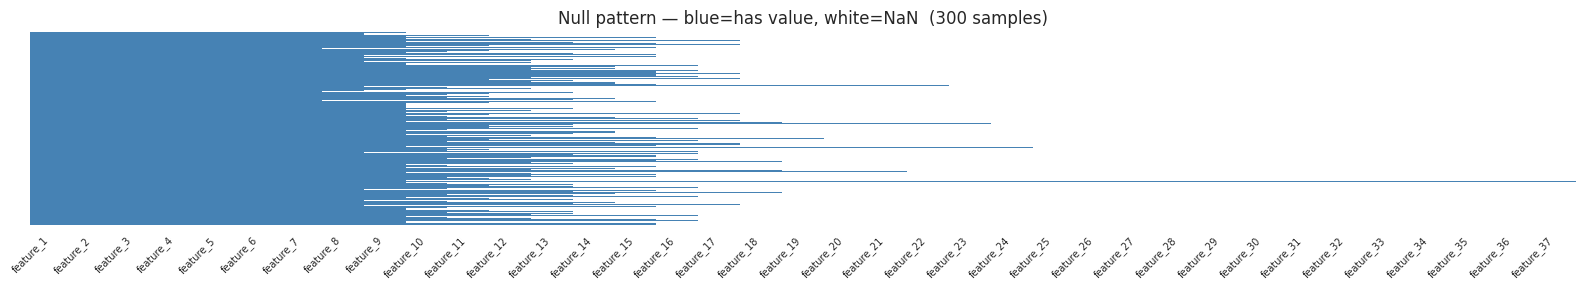


=== Meta cols unique values ===
  feature_1: 120 unique | top5: {760: 8227, 685: 7919, 836: 4153, 7943: 4116, 10477: 4104}
  feature_2: 107 unique | top5: {105: 7233, 1165: 4156, 697: 4104, 1593: 4071, 2207: 4033}
  feature_3: 167 unique | top5: {8615: 8104, 105: 6848, 102: 4655, 21355: 1149, 20022: 1149}
  feature_4: 182 unique | top5: {105.0: 8864, 102.0: 5886, 103.0: 1768, 1749.0: 1724, 906.0: 1119}
  feature_5: 189 unique | top5: {103.0: 5703, 606.0: 4021, 102.0: 3623, 105.0: 2323, 694.0: 1840}
  feature_6: 193 unique | top5: {103.0: 4885, 867.0: 2428, 929.0: 2353, 24438.0: 2108, 105.0: 1728}
  feature_7: 195 unique | top5: {103.0: 4773, 105.0: 3239, 24438.0: 2615, 735.0: 2537, 697.0: 2013}


In [ ]:
null_pct  = X_train.isnull().mean() * 100
meta_cols = [c for c in X_train.columns if null_pct[c] < 1.0]
seq_cols  = [c for c in X_train.columns if null_pct[c] >= 1.0]

print(f'Meta cols ({len(meta_cols)}): {meta_cols}')
print(f'Seq cols  ({len(seq_cols)}): {seq_cols[0]} ... {seq_cols[-1]}')

# Null heatmap
fig, ax = plt.subplots(figsize=(16,3))
sample = np.random.choice(len(X_train), min(300, len(X_train)), replace=False)
sns.heatmap(X_train.iloc[sample].isnull().values,
            cmap=['steelblue','white'], cbar=False, ax=ax,
            xticklabels=list(X_train.columns), yticklabels=False)
ax.set_title('Null pattern — blue=has value, white=NaN  (300 samples)')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout(); plt.show()

# Meta cols unique values
print('\n=== Meta cols unique values ===')
for c in meta_cols:
    print(f'  {c}: {X_train[c].nunique()} unique | top5: {X_train[c].value_counts().head(5).to_dict()}')

## ✂️ Convert rows → sequences

In [ ]:
def row_to_seq(row):
    return [int(v) for v in row[seq_cols].dropna().values]

print('Converting sequences...')
train_seqs = X_train.apply(row_to_seq, axis=1).values
val_seqs   = X_val.apply(row_to_seq,   axis=1).values
test_seqs  = X_test.apply(row_to_seq,  axis=1).values
print(f'Done. Sample: len={len(train_seqs[0])}, values={train_seqs[0][:8]}...')

Converting sequences...
Done. Sample: len=1, values=[849]...


## 📏 Sequence Length Distribution

=== SEQUENCE LENGTH STATS (TRAIN) ===
count    51000.000000
mean         5.826294
std          4.577351
min          0.000000
10%          2.000000
25%          2.000000
50%          5.000000
75%          8.000000
90%         10.000000
95%         12.000000
99%         30.000000
max         30.000000


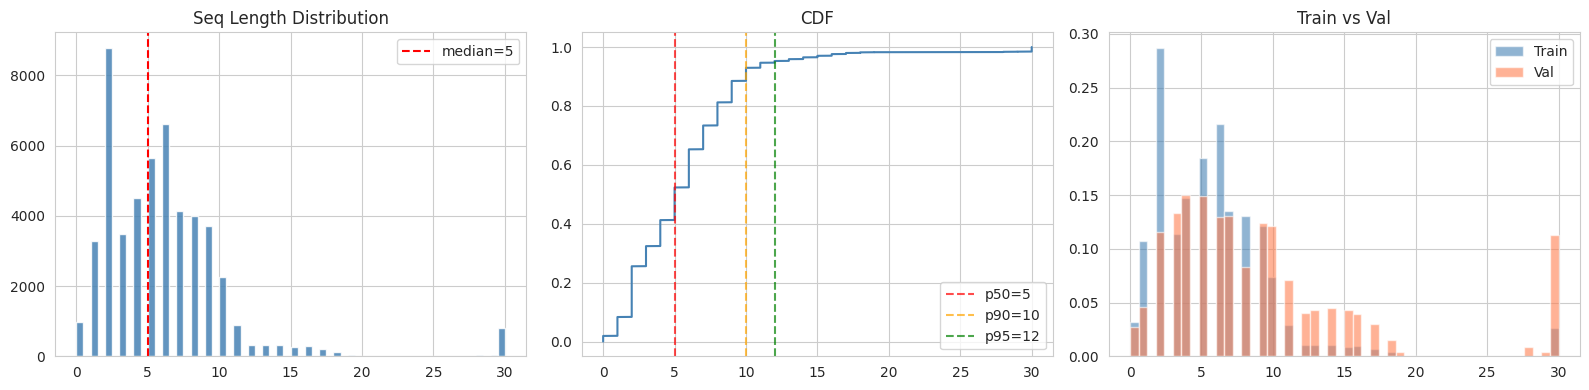


p95 length (dùng làm MAX_LEN): 12


In [ ]:
lengths_tr = np.array([len(s) for s in train_seqs])
lengths_vl = np.array([len(s) for s in val_seqs])

print('=== SEQUENCE LENGTH STATS (TRAIN) ===')
print(pd.Series(lengths_tr).describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).to_string())

fig, axes = plt.subplots(1,3, figsize=(16,4))
axes[0].hist(lengths_tr, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.median(lengths_tr), color='red', linestyle='--', label=f'median={np.median(lengths_tr):.0f}')
axes[0].set_title('Seq Length Distribution'); axes[0].legend()

sorted_l = np.sort(lengths_tr)
axes[1].plot(sorted_l, np.arange(1,len(sorted_l)+1)/len(sorted_l), 'steelblue')
for p,c in [(50,'red'),(90,'orange'),(95,'green')]:
    xp = np.percentile(lengths_tr,p)
    axes[1].axvline(xp, color=c, linestyle='--', alpha=.7, label=f'p{p}={xp:.0f}')
axes[1].set_title('CDF'); axes[1].legend()

axes[2].hist(lengths_tr, bins=50, alpha=.6, label='Train', color='steelblue', density=True)
axes[2].hist(lengths_vl, bins=50, alpha=.6, label='Val',   color='coral',     density=True)
axes[2].set_title('Train vs Val'); axes[2].legend()
plt.tight_layout(); plt.show()

MAX_LEN_P95 = int(np.percentile(lengths_tr, 95))
print(f'\np95 length (dùng làm MAX_LEN): {MAX_LEN_P95}')

## 🔤 Vocabulary Analysis

Total tokens (w/ repeat): 297,141
Unique token types:       236
Token range:              102 – 24438
Top 20: [(105, 26243), (102, 24048), (8615, 9243), (103, 8200), (697, 6852), (975, 6139), (760, 6114), (1068, 5606), (685, 5369), (21355, 4754), (15342, 4739), (21606, 4715), (17980, 4714), (21040, 4664), (20278, 4638), (20022, 4553), (15881, 4310), (1027, 4110), (995, 4104), (1080, 4100)]

Very common (>10% sessions): 9 → likely action types: [102, 103, 105, 685, 697, 760, 975, 1068, 8615]
Common (1-10%):              98
Rare (<1%):                  129 → likely product/order IDs


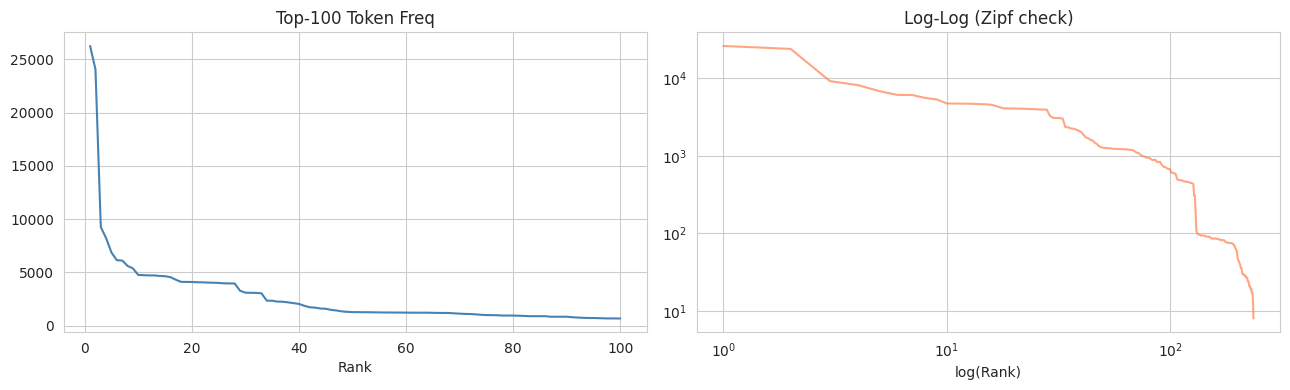

In [ ]:
all_tokens    = [t for s in train_seqs for t in s]
token_counter = Counter(all_tokens)
N_train       = len(train_seqs)

print(f'Total tokens (w/ repeat): {len(all_tokens):,}')
print(f'Unique token types:       {len(token_counter):,}')
print(f'Token range:              {min(token_counter)} – {max(token_counter)}')
print(f'Top 20: {token_counter.most_common(20)}')

very_common = {t for t,f in token_counter.items() if f/N_train > 0.10}
common      = {t for t,f in token_counter.items() if 0.01 < f/N_train <= 0.10}
rare        = {t for t,f in token_counter.items() if f/N_train <= 0.01}
print(f'\nVery common (>10% sessions): {len(very_common)} → likely action types: {sorted(very_common)}')
print(f'Common (1-10%):              {len(common)}')
print(f'Rare (<1%):                  {len(rare):,} → likely product/order IDs')

freqs = sorted(token_counter.values(), reverse=True)
ranks = np.arange(1, len(freqs)+1)
fig, axes = plt.subplots(1,2, figsize=(13,4))
axes[0].plot(ranks[:100], freqs[:100], 'steelblue')
axes[0].set_title('Top-100 Token Freq'); axes[0].set_xlabel('Rank')
axes[1].loglog(ranks, freqs, 'coral', alpha=.7)
axes[1].set_title('Log-Log (Zipf check)'); axes[1].set_xlabel('log(Rank)')
plt.tight_layout(); plt.show()

## 🎯 Target Distribution

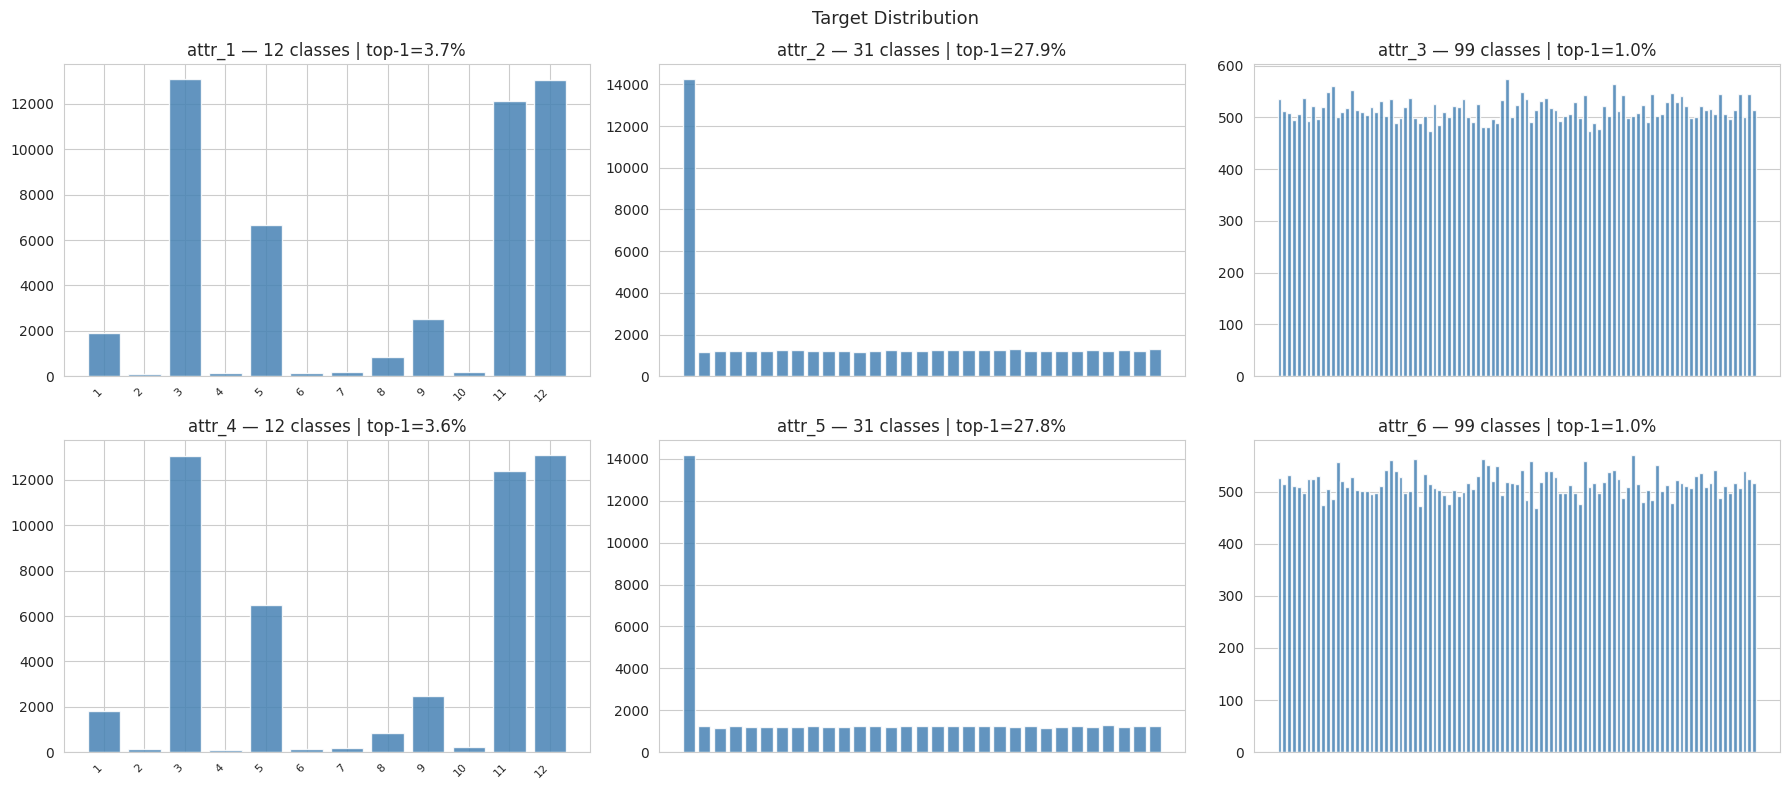

=== CLASS COUNT & IMBALANCE ===
  attr_1:  12 classes | top-1=25.7% ✅
  attr_2:  31 classes | top-1=27.9% ✅
  attr_3:  99 classes | top-1=1.1% ✅
  attr_4:  12 classes | top-1=25.7% ✅
  attr_5:  31 classes | top-1=27.8% ✅
  attr_6:  99 classes | top-1=1.1% ✅


In [ ]:
fig, axes = plt.subplots(2,3, figsize=(18,8))
for i, col in enumerate(TARGET_COLS):
    ax = axes[i//3][i%3]
    vc = Y_train[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white', alpha=.85)
    top1 = vc.iloc[0]/len(Y_train)*100
    ax.set_title(f'{col} — {Y_train[col].nunique()} classes | top-1={top1:.1f}%')
    if Y_train[col].nunique() > 20: ax.set_xticks([])
    else: plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.suptitle('Target Distribution', fontsize=13)
plt.tight_layout(); plt.show()

print('=== CLASS COUNT & IMBALANCE ===')
for col in TARGET_COLS:
    vc = Y_train[col].value_counts()
    flag = '⚠️ IMBALANCED' if vc.iloc[0]/len(Y_train) > 0.5 else '✅'
    print(f'  {col}: {Y_train[col].nunique():3d} classes | top-1={vc.iloc[0]/len(Y_train)*100:.1f}% {flag}')

## 🔗 Target Correlation

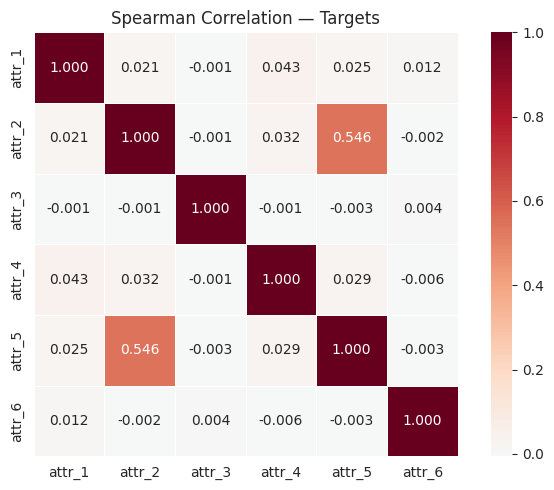

High correlation pairs (|r|>0.3):
  attr_2 ↔ attr_5: 0.546 ← khai thác stacking!


In [ ]:
corr = Y_train[TARGET_COLS].rank().corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=.5)
plt.title('Spearman Correlation — Targets')
plt.tight_layout(); plt.show()
print('High correlation pairs (|r|>0.3):')
for i in range(len(TARGET_COLS)):
    for j in range(i+1, len(TARGET_COLS)):
        r = corr.iloc[i,j]
        if abs(r) > 0.3:
            print(f'  {TARGET_COLS[i]} ↔ {TARGET_COLS[j]}: {r:.3f} ← khai thác stacking!')

## 💾 Save outputs → NB-02 dùng

In [ ]:
# Encode targets
encoders = {}
Y_train_enc = Y_train.copy()
Y_val_enc   = Y_val.copy()
for col in TARGET_COLS:
    le = LabelEncoder()
    Y_train_enc[col] = le.fit_transform(Y_train[col])
    Y_val_enc[col]   = le.transform(Y_val[col])
    encoders[col]    = le

# Save tất cả
with open('/content/drive/MyDrive/sailormoon/data/pipeline/sequences.pkl','wb') as f:
    pickle.dump({'train':train_seqs,'val':val_seqs,'test':test_seqs}, f)
with open('/content/drive/MyDrive/sailormoon/data/pipeline/meta.pkl','wb') as f:
    pickle.dump({'meta_cols':meta_cols,'seq_cols':seq_cols,
                 'max_len_p95':MAX_LEN_P95,'N_train':N_train}, f)
with open('/content/drive/MyDrive/sailormoon/data/pipeline/encoders.pkl','wb') as f:
    pickle.dump(encoders, f)
with open('/content/drive/MyDrive/sailormoon/data/pipeline/token_stats.pkl','wb') as f:
    pickle.dump({'counter':token_counter,'very_common':very_common,
                 'common':common,'rare':rare}, f)

Y_train_enc.to_csv('/content/drive/MyDrive/sailormoon/data/pipeline/Y_train_enc.csv')
Y_val_enc.to_csv('/content/drive/MyDrive/sailormoon/data/pipeline/Y_val_enc.csv')
Y_train.to_csv('/content/drive/MyDrive/sailormoon/data/pipeline/Y_train_orig.csv')
Y_val.to_csv('/content/drive/MyDrive/sailormoon/data/pipeline/Y_val_orig.csv')

print('✅ Saved to /content/drive/MyDrive/sailormoon/data/pipeline/')
print('   → sequences.pkl, meta.pkl, encoders.pkl, token_stats.pkl')
print('   → Y_train_enc.csv, Y_val_enc.csv')

✅ Saved to /content/drive/MyDrive/sailormoon/data/pipeline/
   → sequences.pkl, meta.pkl, encoders.pkl, token_stats.pkl
   → Y_train_enc.csv, Y_val_enc.csv

➡️  Next: NB-02_feature_engineering.ipynb
